In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import Input
from keras.models import Sequential
from keras.models import Model
from keras.layers import Conv1D, Conv2D, Dense, BatchNormalization, Flatten, MaxPooling2D, Activation
from keras.layers import Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [11]:
pip install np_utils

In [29]:
#download the weather images and put them in a directory
path = r'/Users/artoe/Documents/DataAnalytics/Machine Learning With Python/Achievement 2/data/Multi-class Weather Dataset'
folders = os.listdir(path)
print(folders)

['Cloudy', 'Rain', 'Shine', 'Sunrise']


In [31]:
#this will load in the pictures and rescale them to 250x250pixels

datagenerator = ImageDataGenerator(rescale=1/255, validation_split=0.2)
train_generator = datagenerator.flow_from_directory(
    path,
    target_size=(250 , 250),
    batch_size=32,
    subset='training',
)

test_generator = datagenerator.flow_from_directory(
    path,
    target_size=(250 , 250),
    batch_size=32,
    subset='validation',
)

Found 901 images belonging to 4 classes.
Found 224 images belonging to 4 classes.


In [86]:
#this is a CNN to categorize the weather images

inputs = Input(shape=(250, 250, 3))
epochs = 45
learning_rate = 0.01
x = Conv2D(32, (5,5), activation = 'relu')(inputs)
x = MaxPooling2D(3,3)(x)
x = Conv2D(64, (5,5) , activation = 'relu')(x)
x = MaxPooling2D((3,3))(x)
x = Conv2D(128 , (5,5) , activation = 'relu')(x)
x = MaxPooling2D(3,3)(x)
x = Flatten()(x)
x = Dropout(0.5, seed = 5)(x)
x = Dense(128 , activation = 'relu')(x)

outputs = Dense(4, activation = 'softmax')(x)

model:Model = Model(inputs=inputs, outputs=outputs)

In [88]:
#compile and run the model
#how many epochs are required to generate an accurate model?

model.compile(optimizer='Adam', loss="mean_squared_error", metrics=["accuracy"])
model.fit(
    train_generator, 
    epochs = epochs, #<----FILL THIS IN!
    steps_per_epoch = train_generator.n // train_generator.batch_size,
    validation_data = test_generator,
    validation_steps = test_generator.n // test_generator.batch_size,
)

Epoch 1/45
28/28 ━━━━━━━━━━━━━━━━━━━━ 18s 611ms/step - accuracy: 0.4315 - loss: 0.1531 - val_accuracy: 0.6741 - val_loss: 0.1274
Epoch 2/45
 1/28 ━━━━━━━━━━━━━━━━━━━━ 16s 606ms/step - accuracy: 0.8125 - loss: 0.0753

C:\Users\artoe\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.8125 - loss: 0.0753 - val_accuracy: 0.6920 - val_loss: 0.1309
Epoch 3/45
28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 748ms/step - accuracy: 0.7529 - loss: 0.0872 - val_accuracy: 0.7589 - val_loss: 0.1184
Epoch 4/45
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.7500 - loss: 0.1083 - val_accuracy: 0.6920 - val_loss: 0.1323
Epoch 5/45
28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 755ms/step - accuracy: 0.7734 - loss: 0.0862 - val_accuracy: 0.7188 - val_loss: 0.1022
Epoch 6/45
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.7500 - loss: 0.0747 - val_accuracy: 0.6205 - val_loss: 0.1385
Epoch 7/45
28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 737ms/step - accuracy: 0.7556 - loss: 0.0855 - val_accuracy: 0.8259 - val_loss: 0.0653
Epoch 8/45
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.7500 - loss: 0.0631 - val_accuracy: 0.8304 - val_loss: 0.0690
Epoch 9/45
28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 744ms/step - accuracy: 0.8550 - loss: 0.0550 - val_accuracy: 0.8304 - val

In [89]:
results = pd.DataFrame(model.history.history)

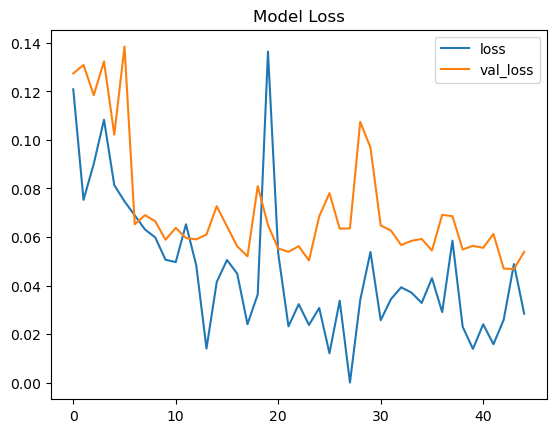

In [92]:
results[['loss','val_loss']].plot(title='Model Loss')
plt.savefig('./loss.png')

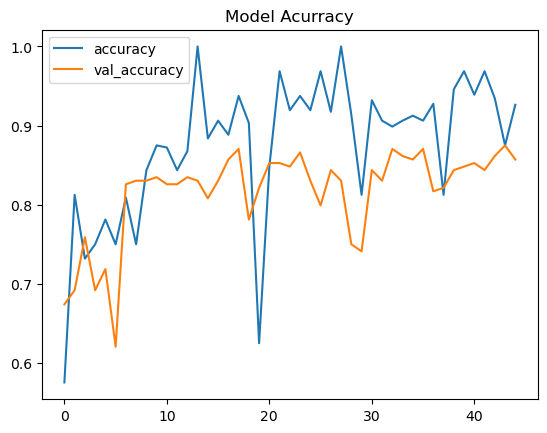

In [94]:
results[['accuracy','val_accuracy']].plot(title='Model Acurracy')
plt.savefig('./accuracy.png')

In [96]:
# Print the accuracy and loss
print("Accuracy: {}, Val_Accuracy: {}".format(results['accuracy'].iloc[-1], results['val_accuracy'].iloc[-1]))
print("Loss: {}, Val_Loss: {}".format(results['loss'].iloc[-1], results['val_loss'].iloc[-1]))

Accuracy: 0.9263521432876587, Val_Accuracy: 0.8571428656578064
Loss: 0.028432529419660568, Val_Loss: 0.053931884467601776


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step


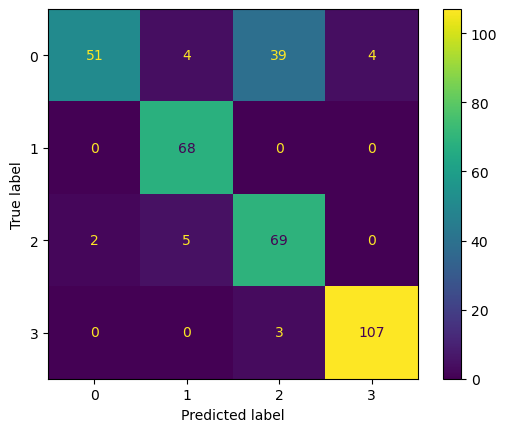

In [98]:
# collect n batches of images and display the confusion matrix for them.

class_names = ['Cloudy', 'Rain', 'Shine', 'Sunrise']
n = 10 #<--you can change the number of batches selected.

image_batch, classes_batch = next(test_generator)

for batch in range(n):
    temp = next(test_generator)
    image_batch = np.concatenate((image_batch, temp[0]))
    classes_batch = np.concatenate((classes_batch, temp[1]))

classes_batch = classes_batch
y_predict = model.predict(image_batch)

#Confusion matrix for training data
cm = confusion_matrix(y_pred = [np.argmax(x) for x in y_predict], y_true = [np.argmax(x) for x in classes_batch])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [100]:
#This function will display a number of random images as well as the predictions for the type of weather.

def predict_one(model, num_images = None):  
    image_batch, classes_batch = next(test_generator)
    predicted_batch = model.predict(image_batch)
    for k in range(0,image_batch.shape[0] if num_images is None else num_images):
        image = image_batch[k]
        real_class = class_names[np.argmax(classes_batch[k])]
        predicted_class = class_names[np.argmax(predicted_batch[k])]
        value_predicted = predicted_batch[k]
        isTrue = (real_class == predicted_class)
        plt.figure(k)
        plt.title(str("Correct Prediction" if isTrue else "Incorrect Prediction") + ' - class: ' + real_class + ' - ' + 'predicted: ' + predicted_class + str(value_predicted))
        plt.axis('off')
        plt.savefig('./' + real_class + '_' + predicted_class + '_' + str(value_predicted) + '.png')
        plt.imshow(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


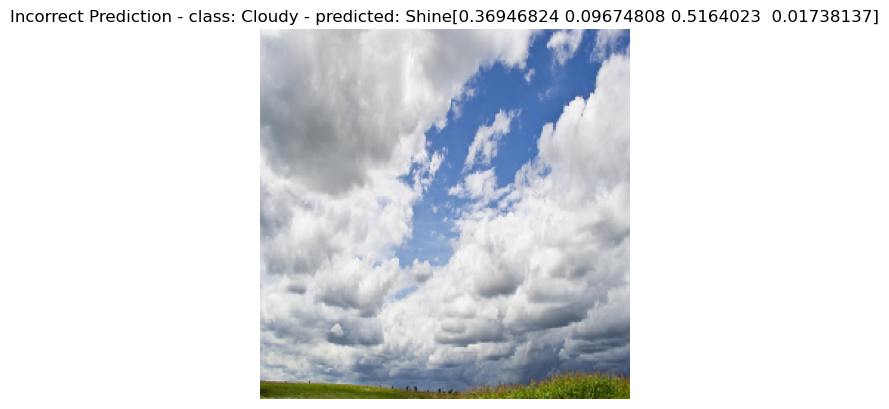

In [131]:
predict_one(model, 1) #<--you can show multiple pictures with this command. Just fill in the number you want to see.